In [31]:
import os
import numpy as np
from collections.abc import Callable
import matplotlib.pyplot as plt
import pandas as pd

In [41]:
def maximum_error(solution, B):
  errors = [np.abs(solution(x) - y) for x, y in B]
  return np.round(np.max(errors), 4)

In [4]:
def euler_method(f, x0, y0, h, n):
  results = []
  x = x0
  y = y0

  results.append((x, y))

  for _ in range(n):
    y = y + h * f(x, y)
    x = x + h
    results.append((x, y))

  return results

In [25]:
def runge_kutta_method(f, t0, y0, h, n_steps):
  t = t0
  y = y0
  result = [(t, y)]

  for _ in range(n_steps):
    k1 = f(t, y)
    k2 = f(t + h / 2, y + h / 2 * k1)
    k3 = f(t + h / 2, y + h / 2 * k2)
    k4 = f(t + h, y + h * k3)

    y = y + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
    t = t + h
    result.append((t, y))

  return result

In [6]:
x0 = np.pi/4
x1 = 3 * np.pi
m = 2
k = 1

In [7]:
equation = lambda x,y: k**2 * m * np.sin(m*x) * np.cos(m*x) + k * m * y * np.sin(m*x)
solution = lambda x: np.exp(-k * np.cos(m*x)) - k * np.cos(m*x) + 1

In [45]:

def plot_solution(
  f_exact: Callable[[float], float],
  method_results: dict,
  x_range: tuple[float, float],
  parameter,
  title: str = 'Rozwiązanie równania różniczkowego',
  x_points: int = 1000
):
  x_vals = np.linspace(x_range[0], x_range[1], x_points)

  plt.figure(figsize=(10, 6))
  plt.plot(x_vals, [f_exact(x) for x in x_vals], label="Dokładne rozwiązanie", color='black')

  for method_name, points in method_results.items():
    points = np.array(points)
    plt.plot(points[:, 0], points[:, 1], '--', label=f"{method_name}")

  plt.xlabel("x")
  plt.ylabel("y")
  plt.title(title)
  plt.legend()
  plt.grid(True)
  plt.savefig(f"data/{parameter}.png")
  plt.show()

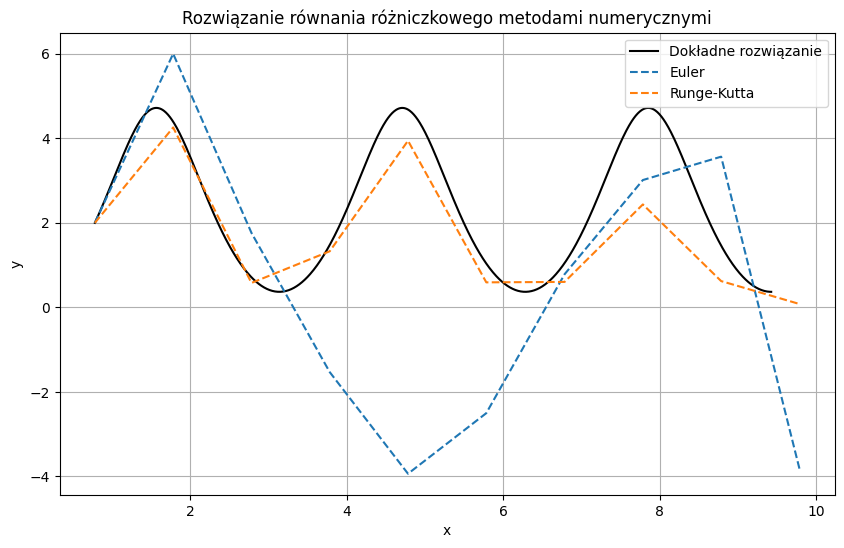

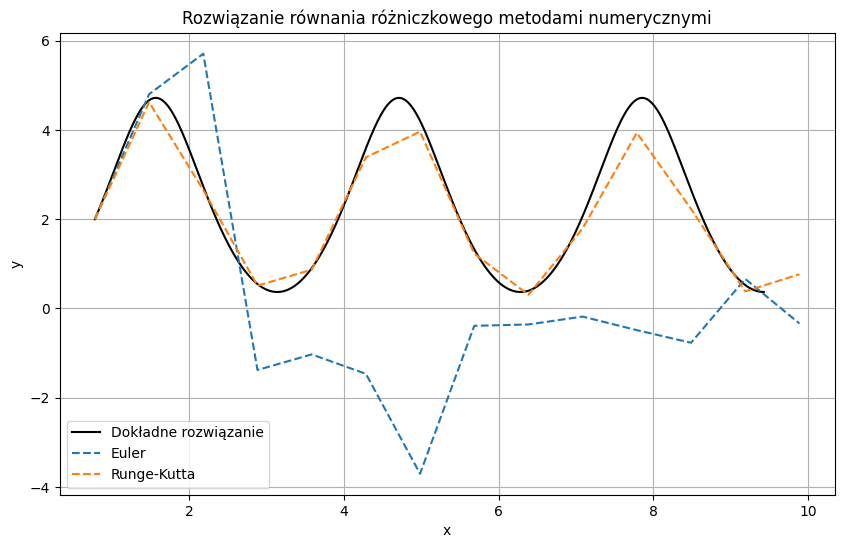

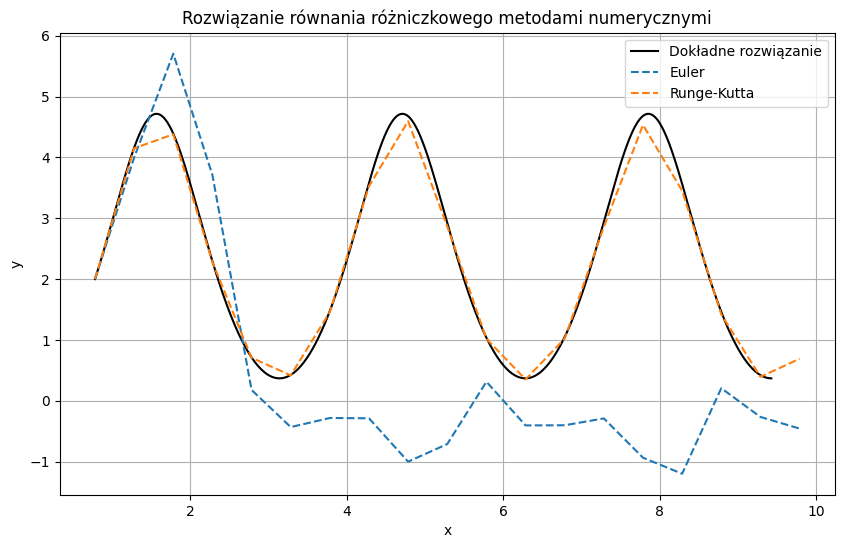

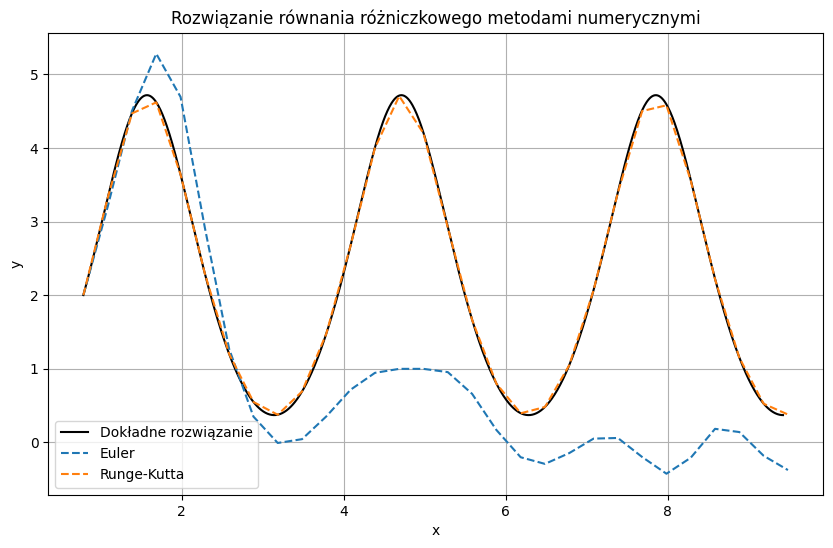

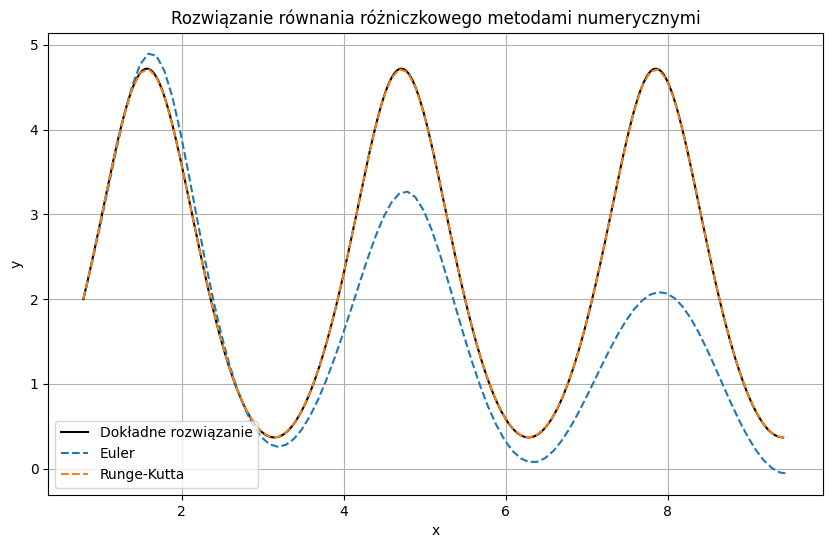

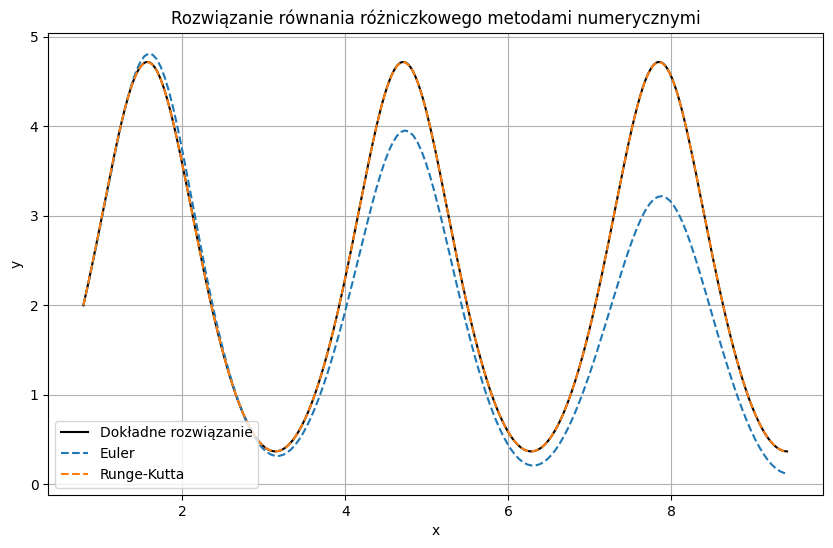

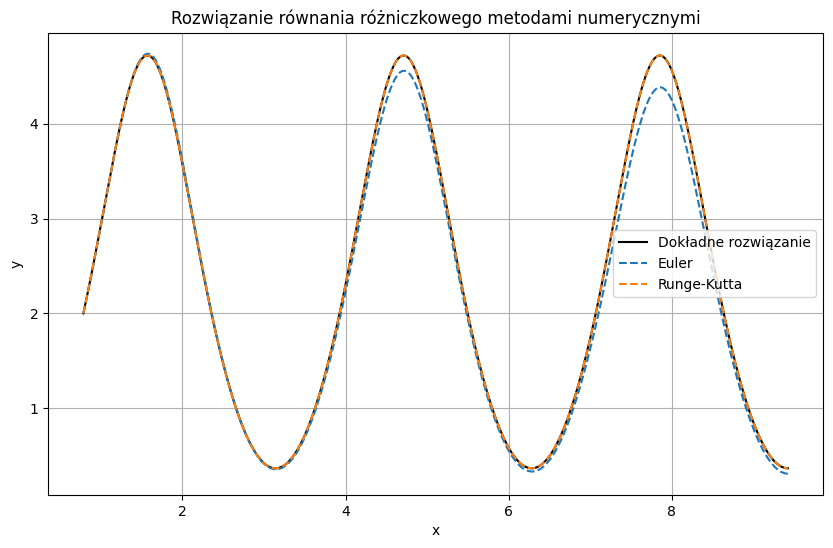

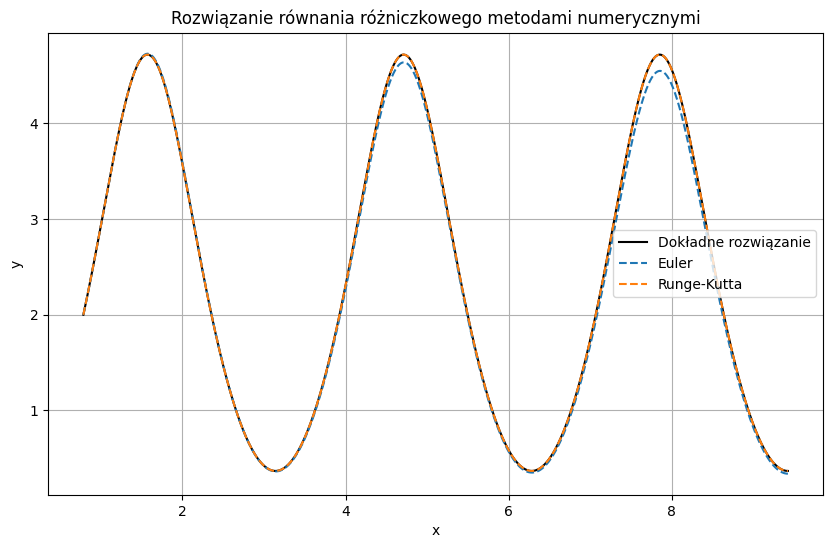

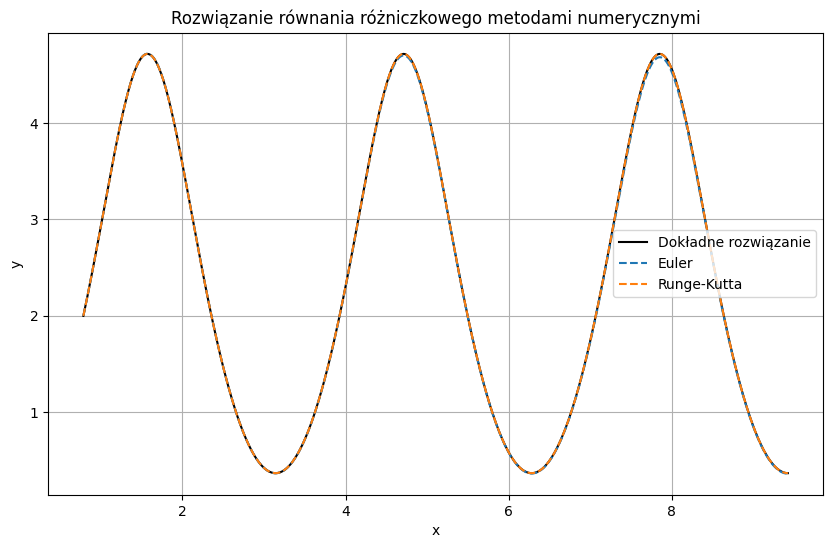

In [46]:
if not os.path.exists("data"):
  os.mkdir("data")

ds = [1, 0.7, 0.5, 0.3, 0.1, 0.05, 0.01, 0.005, 0.001]
errors_euler = []
errors_runge_kutta = []
y0 = solution(x0)


for d in ds:
    n_steps = int((x1-x0 ) / d ) + 1
    
    euler = euler_method(equation, x0, y0, d, n_steps)
    runge_kutta = runge_kutta_method(equation, x0, y0, d, n_steps)
    
    plot_solution(
      f_exact=solution,
      method_results={
        "Euler": euler,
        "Runge-Kutta": runge_kutta
      },
      parameter=d,
      x_range=(x0, x1),
      title="Rozwiązanie równania różniczkowego metodami numerycznymi"
    )
    errors_euler.append(maximum_error(solution, euler))
    errors_runge_kutta.append(maximum_error(solution, runge_kutta))

df = pd.DataFrame({
    "d": ds,
    "max_error_euler": errors_euler,
    "max_error_runge_kutta": errors_runge_kutta
})
df.to_csv("data/errors.csv", index=False)
    
